In [56]:
#load package
library(dplyr)
library(Biostrings)
library(ggplot2)
library(dplyr)
library(data.table)
library(rtracklayer)
library(dplyr)
library(ggbio)
library(reshape2)
library(ggsci)
library(viridis)
library(ggpubr)
library(ggh4x)
library(khroma)
library(qs)
MySplit = function(str,sep, n){
  return(unlist(lapply(strsplit(str,sep),"[[",n)))
}

## Figure 5a

In [ ]:
umap_df_hub = qread("umap_plot/umap_df_25_08_22.qs")

In [ ]:
p1.0 = ggplot(umap_df_hub, aes(x = UMAP1, y = UMAP2,color = condition)) +
  geom_point(size = 0.1, alpha = 0.8) +
 # geom_point(data = umap_df_hub[umap_df_hub$species == "Clostridioides difficile",],
 #            aes(x = UMAP1, y = UMAP2),color = "red",shape = 5, size = 2, alpha = 0.8) + 
  theme_pubr() +
  scale_color_brewer(palette = "Paired") +
  labs(title = "UMAP of different treatment") + 
  facet_wrap(~treat) +
  theme(legend.position = "bottom") +
  guides(color = guide_legend(override.aes = list(size=4)),size = "none")
p1.0
ggexport(p1.0,filename = "../downstream_analysis/figures/UMAP_plot_diff_treatment_25_10_10.pdf",width = 10,height = 6)

## Figure5b

In [3]:
vrdf.a1 = read.delim("cd_scdata/A1_abricate_ana.txt",header = F)
vrdf.a2 = read.delim("cd_scdata/A2_abricate_ana.txt",header = F)
vrdf.b1 = read.delim("cd_scdata/B1_abricate_ana.txt",header = F)
vrdf.b2 = read.delim("cd_scdata/B2_abricate_ana.txt",header = F)
vrdf.f1 = read.delim("cd_scdata/C282-1_abricate_ana.txt",header = F)
vrdf.f2 = read.delim("cd_scdata/C282-2_abricate_ana.txt",header = F)
vrdf.f3 = read.delim("cd_scdata/C282_3_abricate_ana.txt",header = F)
vrdf.v1 = read.delim("cd_scdata/C295-1_abricate_ana.txt",header = F)
vrdf.v2 = read.delim("cd_scdata/C295-2_abricate_ana.txt",header = F)
vrdf.v3 = read.delim("cd_scdata/C295-3_abricate_ana.txt",header = F)

In [37]:
vrdf.a1$sample = "A1";vrdf.a1$group = "FMT2";vrdf.a1$condition = "Pretreatment"
vrdf.a2$sample = "A2";vrdf.a2$group = "FMT2";vrdf.a2$condition = "Posttreatment"
vrdf.b1$sample = "B1";vrdf.b1$group = "Vancomycin2";vrdf.b1$condition = "Pretreatment"
vrdf.b2$sample = "B2";vrdf.b2$group = "Vancomycin2";vrdf.b2$condition = "Posttreatment"
vrdf.f1$sample = "C282_1";vrdf.f1$group = "Vancomycin1";vrdf.f1$condition = "Pretreatment"
vrdf.f2$sample = "C282_2";vrdf.f2$group = "Vancomycin1";vrdf.f2$condition = "Ontreatment"
vrdf.f3$sample = "C282_3";vrdf.f3$group = "Vancomycin1";vrdf.f3$condition = "Posttreatment"
vrdf.v1$sample = "C295_1";vrdf.v1$group = "FMT1";vrdf.v1$condition = "Pretreatment"
vrdf.v2$sample = "C295_2";vrdf.v2$group = "FMT1";vrdf.v2$condition = "Ontreatment"
vrdf.v3$sample = "C295_3";vrdf.v3$group = "FMT1";vrdf.v3$condition = "Posttreatment"
vrdft = rbind(vrdf.a1,vrdf.a2,vrdf.b1,vrdf.b2,vrdf.f1,vrdf.f2,vrdf.f3,vrdf.v1,vrdf.v2,vrdf.v3)
colnames(vrdft) = c('name','contig','start','end','gene','cov_map','gaps','cov_percent',
                    'identity','database','accession',"sample","group","condition")
vrdft$treat = substr(vrdft$group,1,nchar(vrdft$group) - 1)
head(vrdft)

,name,contig,start,end,gene,cov_map,gaps,cov_percent,identity,database,accession,sample,group,condition,treat
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AAACCTG_AAACGTC_AGCTCCT,utg000134l,1338,1980,catD,1-639/639,5/6,99.84,98.913,ncbi,NG_047622.1,A1,FMT2,Pretreatment,FMT
2,AAACCTG_AACCATG_TTAGGCA,utg000173l,2507,4427,tet(O),1-1920/1920,1/1,100.00,99.844,ncbi,NG_048264.1,A1,FMT2,Pretreatment,FMT
3,AAACCTG_AACCATG_TTAGGCA,utg000176l,1,75,tet(32),1-75/1920,0/0,3.91,100.000,ncbi,NG_048124.1,A1,FMT2,Pretreatment,FMT
4,AAACCTG_AATCGGT_CGGAGTC,utg000003l,1683,2901,mef(A),1-1219/1227,0/0,99.35,97.129,ncbi,NG_047970.1,A1,FMT2,Pretreatment,FMT
5,AAACCTG_AATCGGT_CGGAGTC,utg000003l,3021,4473,msr(D),1-1454/1464,1/1,99.25,92.160,ncbi,NG_048005.1,A1,FMT2,Pretreatment,FMT
6,AAACCTG_AATCGGT_GCATGAT,utg000046l,1944,2205,lnu(C),226-490/495,1/3,52.93,75.849,ncbi,NG_047924.1,A1,FMT2,Pretreatment,FMT


In [174]:
library(GenomicRanges)
vrdft$contig = paste0(vrdft$name,"-",vrdft$contig)
gr_resistance <- GRanges(
    seqnames = vrdft$contig,
    ranges = IRanges(start = vrdft$start, end = vrdft$end),
    gene_id = vrdft$gene)

overlap_pairs <- findOverlaps(gr_resistance, gr_resistance)

overlap_pairs <- overlap_pairs[queryHits(overlap_pairs) != subjectHits(overlap_pairs)]


overlap_pairs
hits_matrix <- as.matrix(overlap_pairs)
keep <- rep(TRUE, length(gr_resistance))

for (i in seq_len(nrow(hits_matrix))) {
    idx1 <- hits_matrix[i, 1]
    idx2 <- hits_matrix[i, 2]

    if (keep[idx1] && keep[idx2]) {
        len1 <- width(gr_resistance)[idx1]
        len2 <- width(gr_resistance)[idx2]

        if (len1 >= len2) {
            keep[idx2] <- FALSE
        } else {
            keep[idx1] <- FALSE
        }
    }
}

indices_to_remove <- which(!keep)
length(indices_to_remove)

Hits object with 4640 hits and 0 metadata columns:
         queryHits subjectHits
         <integer>   <integer>
     [1]        11          14
     [2]        14          11
     [3]        33          34
     [4]        34          33
     [5]        56          57
     ...       ...         ...
  [4636]     55024       55023
  [4637]     55031       55033
  [4638]     55033       55031
  [4639]     55085       55086
  [4640]     55086       55085
  -------
  queryLength: 55090 / subjectLength: 55090

[1] 2251

In [179]:
length(gr_resistance)
vrdft = vrdft[-indices_to_remove,]

[1] 55090

In [38]:
vrdft[vrdft$group %in% c("FMT1","Vancomycin1"),]$name = paste0(vrdft[vrdft$group %in% c("FMT1","Vancomycin1"),]$sample,"_",
                                                               vrdft[vrdft$group %in% c("FMT1","Vancomycin1"),]$name)

In [63]:
anotdf = read.csv("all_ani_total_25_08_20.csv")
tax_df = read.csv("refdata/taxon_class_08_21.csv")
anotdf = merge(anotdf,tax_df,by = "species")
head(anotdf)

,species,name,GCA,ANI,db,sample,group,condition,order,class
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,[Clostridium] asparagiforme,C295_2_lib1_out_AAGGTTCACAGCACCTTAGTCATACAGTG,GCF_025149125.1,99.36,refseq,C295_2,FMT,Ontreatment,Eubacteriales,Clostridia
2,[Clostridium] asparagiforme,C295_1_lib2_out_GCGCCAAACAGAATCGGTGTCATAAGCGT,GCF_025149125.1,95.64,refseq,C295_1,FMT,Pretreatment,Eubacteriales,Clostridia
3,[Clostridium] asparagiforme,C295_3_lib1_out_TCGGGACACAGGGCCGATGTCAGCACTCT,GCF_025149125.1,99.85,refseq,C295_3,FMT,Posttreatment,Eubacteriales,Clostridia
4,[Clostridium] asparagiforme,C295_3_lib1_out_GGCAATTACAGTACTTGTGTCATGATTTC,GCF_025149125.1,96.36,refseq,C295_3,FMT,Posttreatment,Eubacteriales,Clostridia
5,[Clostridium] asparagiforme,C295_1_lib2_out_GCAGCCAACAGCTCACACGTCACGAACAT,GCF_025149125.1,95.93,refseq,C295_1,FMT,Pretreatment,Eubacteriales,Clostridia
6,[Clostridium] asparagiforme,C295_1_lib2_out_CTAAGACACAGGATCGTAGTCAAAACAAC,GCF_025149125.1,99.55,refseq,C295_1,FMT,Pretreatment,Eubacteriales,Clostridia


In [64]:
anotdf[anotdf$group == "A",]$group = "FMT2"
anotdf[anotdf$group == "B",]$group = "Vancomycin2"
anotdf[anotdf$group == "FMT",]$group = "FMT1"
anotdf[anotdf$group == "Vancomycin",]$group = "Vancomycin1"

In [27]:
nrow(vrdft)
table(vrdft$group)
vrdft = merge(vrdft,anotdf[,c("name","species","order","class","sample")],by = c("name","sample"))
nrow(vrdft)
table(vrdft$group)

[1] 52737


       FMT1        FMT2 Vancomycin1 Vancomycin2 
      11881        5175       25779        9902 

[1] 52737


       FMT1        FMT2 Vancomycin1 Vancomycin2 
      11881        5175       25779        9902 

In [62]:
vrdft = read.csv("cd_scdata/total_cdgene_list_25_09_12.csv")

In [180]:
write.csv(vrdft,file = "cd_scdata/total_cdgene_list_25_09_12.csv",quote = F, row.names = F)

In [2]:
vrdft = read.csv("cd_scdata/total_cdgene_list_25_09_12.csv")
ctglen = read.delim("cd_scdata/final_table.tsv")
vrdft$contig = MySplit(vrdft$contig,"-",3)
head(vrdft)
head(ctglen)

,name,sample,contig,start,end,gene,cov_map,gaps,cov_percent,identity,database,accession,group,condition,treat,species,order,class,count
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,AAACCTG_AAACGTC_TCTGGAA,A2,AAACCTG_AAACGTC_TCTGGAA-AAACCTG_AAACGTC_TCTGGAA-utg000161l,2243,3695,msr(D),1-1454/1464,1/1,99.25,92.160,ncbi,NG_048005.1,FMT2,Posttreatment,FMT,Mediterraneibacter gnavus,Lachnospirales,Clostridia,1
2,AAACCTG_AAACGTC_TCTGGAA,A2,AAACCTG_AAACGTC_TCTGGAA-AAACCTG_AAACGTC_TCTGGAA-utg000161l,6241,6442,mef(A),1-202/1227,0/0,16.46,98.020,ncbi,NG_047970.1,FMT2,Posttreatment,FMT,Mediterraneibacter gnavus,Lachnospirales,Clostridia,1
3,AAACCTG_AAACGTC_TCTGGAA,A2,AAACCTG_AAACGTC_TCTGGAA-AAACCTG_AAACGTC_TCTGGAA-utg000161l,3815,5033,mef(A),1-1219/1227,0/0,99.35,97.129,ncbi,NG_047970.1,FMT2,Posttreatment,FMT,Mediterraneibacter gnavus,Lachnospirales,Clostridia,1
4,AAACCTG_AACCATG_TTAGGCA,A1,AAACCTG_AACCATG_TTAGGCA-AAACCTG_AACCATG_TTAGGCA-utg000176l,1,75,tet(32),1-75/1920,0/0,3.91,100.000,ncbi,NG_048124.1,FMT2,Pretreatment,FMT,Blautia coccoides,Lachnospirales,Clostridia,1
5,AAACCTG_AACCATG_TTAGGCA,A1,AAACCTG_AACCATG_TTAGGCA-AAACCTG_AACCATG_TTAGGCA-utg000173l,2507,4427,tet(O),1-1920/1920,1/1,100.00,99.844,ncbi,NG_048264.1,FMT2,Pretreatment,FMT,Blautia coccoides,Lachnospirales,Clostridia,1
6,AAACCTG_AACTCAG_TCGAGGC,B2,AAACCTG_AACTCAG_TCGAGGC-AAACCTG_AACTCAG_TCGAGGC-utg000027l,9318,9424,(Phe)catB4,443-549/549,0/0,19.49,99.065,argannot,EU935739:59054-59602,Vancomycin2,Posttreatment,Vancomycin,Raoultella planticola,Enterobacterales,Gammaproteobacteria,1


,Filename,Contig_Name,Length
,<chr>,<chr>,<chr>
1,AAACCTG_AAACGTC_AGCTCCT,utg000001l,LN:i:3949
2,AAACCTG_AAACGTC_AGCTCCT,utg000002l,LN:i:3120
3,AAACCTG_AAACGTC_AGCTCCT,utg000003l,LN:i:1805
4,AAACCTG_AAACGTC_AGCTCCT,utg000004l,LN:i:2368
5,AAACCTG_AAACGTC_AGCTCCT,utg000005l,LN:i:1449
6,AAACCTG_AAACGTC_AGCTCCT,utg000006l,LN:i:3902


In [13]:
# nrow(ctglen)
# ctglen = ctglen[ctglen$Contig_Name %in% vrdft$contig,]
# nrow(ctglen)
# ctglen.hub = ctglen[ctglen$Filename %in% vrdft$name,]
# nrow(ctglen.hub)
#ctglen$Filename = gsub(ctglen$Filename,pattern = "-",replacement = "_")
#table(vrdft[vrdft$name %in% ctglen$Filename,]$sample)
colnames(ctglen) = c("name","contig","length")
nrow(vrdft)
vrdft = merge(vrdft,ctglen,by = c("name","contig"))
nrow(vrdft)

[1] 52839

[1] 52737

In [69]:
### virus ratio in different stage
sample.stc = anotdf %>% dplyr::group_by(group,condition) %>% 
            dplyr::summarise(countt = length(unique(name)))
vr.stc = vrdft %>% dplyr::group_by(group,condition,treat) %>% 
                    dplyr::summarise(count = length(unique(name)),lengthm = mean(length))
vr.stc = merge(vr.stc,sample.stc,by = c("group","condition"))
vr.stc$ratio = vr.stc$count/vr.stc$countt
vr.stc$ratiom = vr.stc$count/vr.stc$countt/vr.stc$lengthm * 100
vr.stc$value = "Cell"
#pbidf.stc
sample.sts = anotdf %>% dplyr::group_by(group,condition) %>% 
            dplyr::summarise(countt = length(unique(species)))
vr.sts = vrdft %>% dplyr::group_by(group,condition,treat) %>% 
                    dplyr::summarise(count = length(unique(species)),lengthm = mean(length))
vr.sts = merge(vr.sts,sample.sts,by = c("group","condition"))
vr.sts$ratio = vr.sts$count/vr.sts$countt
vr.sts$ratiom = vr.sts$count/vr.sts$countt/vr.sts$lengthm * 100
vr.sts$value = "Speicies"
#pbidf.sts
vrdf.st.smp = rbind(vr.stc,vr.sts)
head(vrdf.st.smp)

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
Warning message:
"There were 10 warnings in `dplyr::summarise()`.
The first warning was:
ℹ In argument: `lengthm = mean(length)`.
ℹ In group 1: `group = "FMT1"`, `condition = "Ontreatment"`, `treat = "FMT"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 9 remaining warnings."
`summarise()` has grouped output by 'group', 'condition'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
Warning message:
"There were 10 warnings in `dplyr::summarise()`.
The first warning was:
ℹ In argument: `lengthm = mean(length)`.
ℹ In group 1: `group = "FMT1"`, `condition = "Ontreatment"`, `treat = "FMT"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see 

,group,condition,treat,count,lengthm,countt,ratio,ratiom,value
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<chr>
1,FMT1,Ontreatment,FMT,1887,NA,7298,0.2585640,NA,Cell
2,FMT1,Posttreatment,FMT,1610,NA,5112,0.3149452,NA,Cell
3,FMT1,Pretreatment,FMT,3066,NA,12787,0.2397748,NA,Cell
4,FMT2,Posttreatment,FMT,1252,NA,2123,0.5897315,NA,Cell
5,FMT2,Pretreatment,FMT,946,NA,4510,0.2097561,NA,Cell
6,Vancomycin1,Ontreatment,Vancomycin,2934,NA,8165,0.3593386,NA,Cell


Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `complete.cases()`:
! not all arguments have the same length"
Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `complete.cases()`:
! not all arguments have the same length"
Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `complete.cases()`:
! not all arguments have the same length"
Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `complete.cases()`:
! not all arguments have the same length"


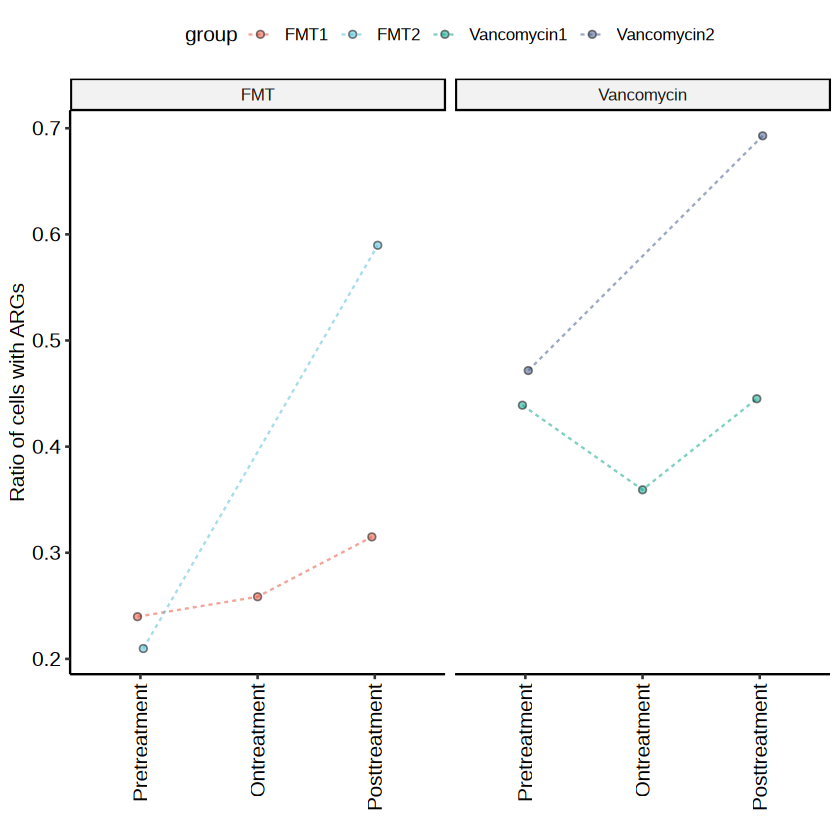

Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `complete.cases()`:
! not all arguments have the same length"
Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `complete.cases()`:
! not all arguments have the same length"
file saved to ../downstream_analysis/figures/f5.1_ARGs_ratio_cell_boxplot_total_25_09_30.pdf

Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `complete.cases()`:
! not all arguments have the same length"
Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `complete.cases()`:
! not all arguments have the same length"
file saved to ../downstream_analysis/figures/f5.1_ARGs_ratio_species_boxplot_total_25_09_30.pdf



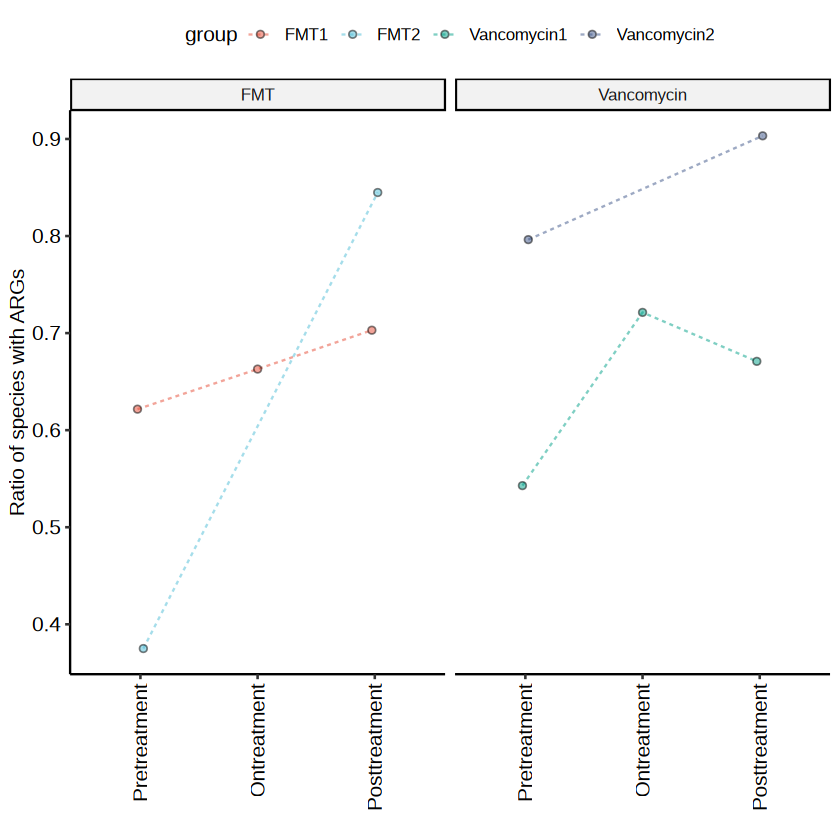

In [71]:
#my_comparisons = list(c("Pretreatment","Posttreatment"))
my_comparisons = list(c("Pretreatment","Ontreatment"),c("Pretreatment","Posttreatment"))
vrdf.st.smp$condition = factor(vrdf.st.smp$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
p1.2 = ggplot(vrdf.st.smp[vrdf.st.smp$value == "Cell",],
              aes(x = condition,y = ratio)) + 
    #geom_boxplot(width = 0.3,lwd = 0.5,outlier.shape = NA) +
    geom_line(aes(group = group,color = group),lwd = 0.5,alpha = 0.5,linetype = 2,position = position_dodge(0.1)) +
    geom_point(aes(group = group,fill = group),size = 1.5,shape = 21,alpha = 0.5,position = position_dodge(0.1)) +
    scale_fill_npg() +
    scale_color_npg() +
    facet_grid(~treat) +
    # scale_fill_manual(values=c("#993365","#666632"))+
    # scale_color_manual(values=c("#993365","#666632"))+
    # scale_fill_brewer(palette='Set3') +
    # scale_color_brewer(palette='Set3') +
    stat_compare_means(paired = TRUE,method = "t.test",comparisons = my_comparisons,
                      method.args = list(alternative = "less")) + theme_pubr() + 
    xlab("") + ylab("Ratio of cells with ARGs") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p1.2
#p1.2
p1.3 = ggplot(vrdf.st.smp[vrdf.st.smp$value == "Speicies",],
              aes(x = condition,y = ratio)) + 
    #geom_boxplot(width = 0.3,lwd = 0.5,outlier.shape = NA) +
    geom_line(aes(group = group,color = group),lwd = 0.5,alpha = 0.5,linetype = 2,position = position_dodge(0.1)) +
    geom_point(aes(group = group,fill = group),size = 1.5,shape = 21,alpha = 0.5,position = position_dodge(0.1)) +
    scale_fill_npg() +
    scale_color_npg() +
    facet_grid(~treat) +
    # scale_fill_manual(values=c("#993365","#666632"))+
    # scale_color_manual(values=c("#993365","#666632"))+
    # scale_fill_brewer(palette='Set3') +
    # scale_color_brewer(palette='Set3') +
    stat_compare_means(paired = TRUE,method = "t.test",comparisons = my_comparisons,
                      method.args = list(alternative = "less")) + theme_pubr() + 
    xlab("") + ylab("Ratio of species with ARGs") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p1.3
ggexport(p1.2, 
         filename = "../downstream_analysis/figures/f5.1_ARGs_ratio_cell_boxplot_total_25_09_30.pdf",
         width = 5,height = 4)
ggexport(p1.3, 
         filename = "../downstream_analysis/figures/f5.1_ARGs_ratio_species_boxplot_total_25_09_30.pdf",
         width = 5,height = 4)

## Figure5c

In [64]:
vrdf.a1 = read.delim("AB_sample/A1_vancomycin.txt",header = F)
vrdf.a2 = read.delim("AB_sample/A2_vancomycin.txt",header = F)
vrdf.b1 = read.delim("AB_sample/B1_vancomycin.txt",header = F)
vrdf.b2 = read.delim("AB_sample/B2_vancomycin.txt",header = F)

vrdf.a1$sample = "A1";vrdf.a1$group = "FMT2";vrdf.a1$condition = "Pretreatment"
vrdf.a2$sample = "A2";vrdf.a2$group = "FMT2";vrdf.a2$condition = "Posttreatment"
vrdf.b1$sample = "B1";vrdf.b1$group = "Vancomycin2";vrdf.b1$condition = "Pretreatment"
vrdf.b2$sample = "B2";vrdf.b2$group = "Vancomycin2";vrdf.b2$condition = "Posttreatment"
vrdf = rbind(vrdf.a1,vrdf.a2,vrdf.b1,vrdf.b2)
head(vrdf)

vrdf.old = read.delim("all_vancomyci_data.txt")
vrdf.old$group = MySplit(vrdf.old$new_name,"_",1)
vrdf.old$condition = MySplit(vrdf.old$new_name,"_",2)
vrdf.old$sample = paste0(vrdf.old$group,"_",vrdf.old$condition)
vrdf.old[vrdf.old$group == "C282",]$group = "Vancomycin1"
vrdf.old[vrdf.old$group == "C295",]$group = "FMT1"
vrdf.old[vrdf.old$condition == "1",]$condition = "Pretreatment"
vrdf.old[vrdf.old$condition == "2",]$condition = "Ontreatment"
vrdf.old[vrdf.old$condition == "3",]$condition = "Posttreatment"
head(vrdf.old)
colnames(vrdf)[1:15] = colnames(vrdf.old)[1:15]
cmid = intersect(colnames(vrdf),colnames(vrdf.old))
vrdf = rbind(vrdf[,cmid],vrdf.old[,cmid])
vrdf$treat = substr(vrdf$group,1,nchar(vrdf$group) - 1)
write.csv(vrdf,file = "cd_scdata/van_cdgene_list_25_09_12.csv",quote = F, row.names = F)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,sample,group,condition
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AGAGCTT_ACAACAC_AAATGAG,utg000035l,7161,7383,vanR-A,467-690/696,1/1,32.04,76.786,ncbi,NG_048402.1,Blautia coccoides,GCF_034355335.1,98.92,refseq,A1,FMT2,Pretreatment
2,ACGATAC_CTTCTCT_GTTGCTT,utg000029l,1817,2035,vanR-Cd,478-696/702,0/0,31.20,76.712,ncbi,NG_061618.1,Thomasclavelia ramosa,GCF_016027135.1,99.2,refseq,A1,FMT2,Pretreatment
3,CGCTTCA_GCTGCTT_TTCGGAC,utg000041l,1,317,vanG-Cd,727-1043/1101,4/6,28.52,75.938,ncbi,NG_061616.1,Thomasclavelia ramosa,GCF_014131695.1,99.23,refseq,A1,FMT2,Pretreatment
4,AAACCTG_AGTTACG_TCAGATG,utg000067l,7,302,vanG-Cd,748-1043/1101,4/6,26.61,76.254,ncbi,NG_061616.1,Thomasclavelia ramosa,GCF_020097255.1,99.19,refseq,A1,FMT2,Pretreatment
5,CTAATGG_GACGTGC_ACACTGA,utg000012l,21858,22040,vanR-A,514-696/696,0/0,26.29,77.049,ncbi,NG_048414.1,unclassfied,none,none,none,A1,FMT2,Pretreatment
6,CAAGAAA_CGACGTT_GGATGTT,utg000060l,1206,1385,vanR-A,514-690/696,2/3,25.43,77.778,ncbi,NG_048402.1,Blautia coccoides,GCF_034355335.1,98.85,refseq,A1,FMT2,Pretreatment


,name,contig,start,end,gene,cov_map,gaps,cov_percent,identity,database,accession,species,GCA,ANI,db,new_name,num,group,condition,sample
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,1085,2227,vanS-Cd,1-1143/1143,0/0,100.00,99.738,ncbi,NG_061619.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin1,Pretreatment,C282_1
2,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,2217,2918,vanR-Cd,1-702/702,0/0,100.00,100.000,ncbi,NG_061618.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin1,Pretreatment,C282_1
3,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,1,824,vanG-Cd,1-863/1101,1/39,74.84,95.133,ncbi,NG_061616.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin1,Pretreatment,C282_1
4,lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,utg000142l,650,1094,vanR-Cd,251-702/702,6/9,63.25,96.247,ncbi,NG_061618.1,Mediterraneibacter gnavus,GCF_016904015.1,99.03,refseq,C282_1_lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,1,Vancomycin1,Pretreatment,C282_1
5,lib1_out_CGCTTCAACAGGCGCGATGTCATCCACAC,utg000050l,754,1194,vanR-Cd,258-702/702,3/4,62.82,97.753,ncbi,NG_061618.1,Mediterraneibacter gnavus,GCF_009831375.1,99.41,refseq,C282_1_lib1_out_CGCTTCAACAGGCGCGATGTCATCCACAC,1,Vancomycin1,Pretreatment,C282_1
6,lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,utg000142l,96,660,vanS-Cd,1-567/1143,5/6,49.26,97.188,ncbi,NG_061619.1,Mediterraneibacter gnavus,GCF_016904015.1,99.03,refseq,C282_1_lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,1,Vancomycin1,Pretreatment,C282_1


In [61]:
vrdf = read.csv("cd_scdata/van_cdgene_list_25_09_12.csv")

`summarise()` has grouped output by 'species', 'gene'. You can override using
the `.groups` argument.
`summarise()` has grouped output by 'species'. You can override using the
`.groups` argument.
file saved to ../downstream_analysis/figures/f5.1_van_ratio_heatmap_species_25_09_12.pdf



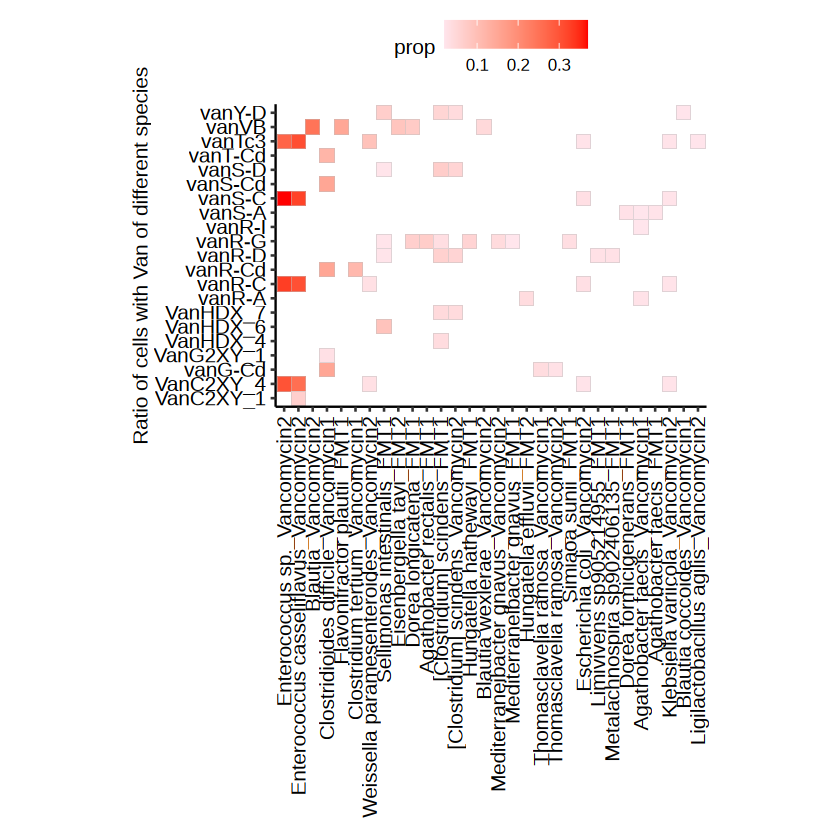

In [126]:
#calculate van gene correlation
vrdf.st.spc = vrdf %>% group_by(species,gene,group) %>% dplyr::summarise(celln = length(unique(name)))
cell.st.spc = anotdf %>% group_by(species,group) %>% dplyr::summarise(cellnt = length(unique(name)))
vrdf.st.spc = merge(vrdf.st.spc,cell.st.spc,by = c("species","group"))
vrdf.st.spc$prop = vrdf.st.spc$celln/vrdf.st.spc$cellnt
vrdf.st.spc = vrdf.st.spc[order(-vrdf.st.spc$prop),]
vrdf.st.spc = vrdf.st.spc[vrdf.st.spc$cellnt > 30,]
vrdf.st.spc = vrdf.st.spc[vrdf.st.spc$prop > 0.02,]
vrdf.st.spc$species = factor(vrdf.st.spc$species,levels = unique(vrdf.st.spc$species))
vrdf.st.spc_complete <- vrdf.st.spc %>%
  tidyr::complete(species,group, gene, fill = list(celln = NA, cellnt = NA, prop = NA))
#vrdf.st.spc_complete = merge(vrdf.st.spc_complete,taxan,by = "species")
vrdf.st.spc$mygroup = paste0(vrdf.st.spc$species,"_",vrdf.st.spc$group)
vrdf.st.spc = vrdf.st.spc[order(vrdf.st.spc$species),]
vrdf.st.spc$mygroup = factor(vrdf.st.spc$mygroup,levels = unique(vrdf.st.spc$mygroup))
p5.0 = ggplot(vrdf.st.spc,aes(x = mygroup,y = gene,fill = prop)) + 
    geom_tile(color = "grey") +
    scale_fill_gradient(low = "#ffe5ec",high = "red",na.value = "white") +
    #scale_fill_viridis(option = "D",na.value = "black") +
    #scale_color_npg() +
    theme_pubr() +
    xlab("") + ylab("Ratio of cells with Van of different species") +
    coord_fixed() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p5.0
#library(aplot)

ggexport(p5.0, 
         filename = "../downstream_analysis/figures/f5.1_van_ratio_heatmap_species_25_09_12.pdf",
         width = 7,height = 6)

In [66]:
### virus ratio in different stage
sample.stc = anotdf %>% dplyr::group_by(group,condition) %>% 
            dplyr::summarise(countt = length(unique(name)))
pbidf.stc = vrdf %>% dplyr::group_by(group,condition,treat) %>% 
                    dplyr::summarise(count = length(unique(name)))
pbidf.stc = merge(pbidf.stc,sample.stc,by = c("group","condition"))
pbidf.stc$ratio = pbidf.stc$count/pbidf.stc$countt
pbidf.stc$value = "Cell"
#pbidf.stc
sample.sts = anotdf %>% dplyr::group_by(group,condition) %>% 
            dplyr::summarise(countt = length(unique(species)))
pbidf.sts = vrdf %>% dplyr::group_by(group,condition,treat) %>% 
                    dplyr::summarise(count = length(unique(species)))
pbidf.sts = merge(pbidf.sts,sample.sts,by = c("group","condition"))
pbidf.sts$ratio = pbidf.sts$count/pbidf.sts$countt
pbidf.sts$value = "Speicies"
#pbidf.sts
vrdf.st.smp = rbind(pbidf.sts,pbidf.stc)
head(vrdf.st.smp)

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'group', 'condition'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'group', 'condition'. You can override
using the `.groups` argument.


,group,condition,treat,count,countt,ratio,value
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>
1,FMT1,Ontreatment,FMT,15,89,0.1685393,Speicies
2,FMT1,Posttreatment,FMT,19,101,0.1881188,Speicies
3,FMT1,Pretreatment,FMT,25,148,0.1689189,Speicies
4,FMT2,Posttreatment,FMT,13,58,0.2241379,Speicies
5,FMT2,Pretreatment,FMT,8,48,0.1666667,Speicies
6,Vancomycin1,Ontreatment,Vancomycin,8,61,0.1311475,Speicies


file saved to ../downstream_analysis/figures/f5.1_van_ratio_line_total_25_09_12.pdf



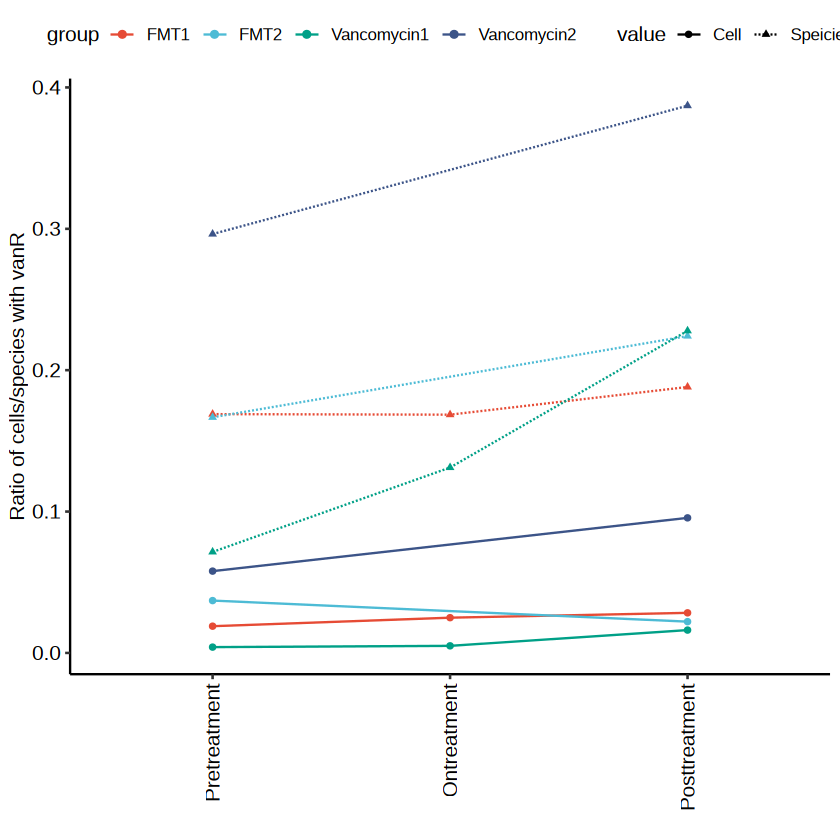

In [69]:
vrdf.st.smp$group2 = paste0(vrdf.st.smp$group,"_",vrdf.st.smp$value)
vrdf.st.smp$condition = factor(vrdf.st.smp$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
p5.1 = ggplot(vrdf.st.smp, aes(x = condition, y = ratio)) +
  geom_line(aes(color = group, group = group2,linetype = value))+
  geom_point(aes(color = group, group = group2,shape = value)) +
  scale_fill_npg() +
  scale_color_npg() +
  xlab("") + ylab("Ratio of cells/species with vanR") + theme_pubr() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p5.1
ggexport(p5.1, 
         filename = "../downstream_analysis/figures/f5.1_van_ratio_line_total_25_09_12.pdf",
         width = 3,height = 4)

In [249]:
graman <- data.frame(
  class = c("Clostridia", "Gammaproteobacteria", "Bacilli", "Negativicutes", 
            "Erysipelotrichia", "Bacteroidia", "Coriobacteriia", "Desulfovibrionia",
            "Verrucomicrobiia", "Actinomycetes", "Tissierellia", "Fusobacteriia", 
            "Epsilonproteobacteria"),
  Gram_Stain = c("Positive", "Negative", "Positive", "Negative", 
                 "Positive", "Negative", "Positive", "Negative",
                 "Negative", "Positive", "Negative", "Negative", 
                 "Negative"))
nrow(vrdf)
vrdf = merge(vrdf,tax_df,by = "species")
vrdf = merge(vrdf,graman,by = "class")
nrow(vrdf)

[1] 1738

[1] 1508

In [254]:
vrdf.stc.mx

species,Gram_Stain,group,Pretreatment,Posttreatment
<chr>,<chr>,<chr>,<dbl>,<dbl>
[Clostridium] innocuum,Positive,Vancomycin2,0.013574661,0.042857143
[Clostridium] scindens,Positive,FMT1,0.100000000,0.252873563
Agathobacter rectalis,Positive,FMT1,0.072932717,0.085308057
Bacteroides fragilis,Negative,FMT1,0.005827506,0.005121639
Clostridioides difficile,Positive,Vancomycin1,0.062500000,0.666666667
Dorea longicatena,Positive,FMT1,0.047619048,0.131313131
Flavonifractor plautii,Positive,FMT1,0.114285714,0.222222222
Mediterraneibacter gnavus,Positive,FMT1,0.009259259,0.027397260
Mediterraneibacter gnavus,Positive,FMT2,0.015718157,0.033003300


In [93]:
### Enrich score analysis
vrdf.st = vrdf %>% group_by(gene,species,sample,group) %>% dplyr::summarise(cellnum_target = length(unique(name)))
vrdf.st = vrdf.st[vrdf.st$cellnum_target > 2,]
length(unique(vrdf.st$species))

anidf.st = anidf %>% group_by(species,sample,group,condition) %>% dplyr::summarise(cellnum_species = length(unique(name)))
vrdf.stt = vrdf %>% group_by(gene,sample,group) %>% dplyr::summarise(cellnum_van = length(unique(name)))

vrdf.st = merge(vrdf.st,anidf.st,by = c("species","group","sample"))
vrdf.st = merge(vrdf.st,vrdf.stt,by = c("gene","group","sample"))
vrdf.st

`summarise()` has grouped output by 'gene', 'species', 'sample'. You can
override using the `.groups` argument.


[1] 33

`summarise()` has grouped output by 'species', 'sample', 'group'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'gene', 'sample'. You can override using
the `.groups` argument.


gene,group,sample,species,cellnum_target,condition,cellnum_species,cellnum_van
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>
VanC2XY_1,B,B2,Enterococcus casseliflavus,22,Posttreatment,331,27
VanC2XY_4,B,B2,Escherichia coli,3,Posttreatment,122,121
VanC2XY_4,B,B2,Enterococcus casseliflavus,85,Posttreatment,331,121
VanC2XY_4,B,B2,Enterococcus sp.,22,Posttreatment,73,121
VanC2XY_4,B,B2,Raoultella planticola,4,Posttreatment,309,121
VanC2XY_5,B,B2,Enterococcus casseliflavus,6,Posttreatment,331,7
vanG-Cd,A,A1,Thomasclavelia ramosa,6,Pretreatment,677,7
vanG-Cd,A,A2,Thomasclavelia ramosa,5,Posttreatment,100,6
vanG-Cd,B,B1,Thomasclavelia ramosa,3,Pretreatment,106,3


In [94]:
# 构建列联表
Enrichanalysis = function(a,b,c,d){
    data <- matrix(c(a, c, b, d), nrow = 2, 
               dimnames = list(
                 c("In_Category", "Not_In_Category"),
                 c("Target_Set", "Background_Set")
               ))

    # Fisher检验
    result <- fisher.test(data, alternative = "greater")
    p_value <- result$p.value
    odds_ratio <- result$estimate
    
    # 富集倍数
    fold_enrich <- (a / (a+b)) / (c / (c+d))
    
    # 输出结果
    res = c("Pvalue" = p_value, 
        "OddsRatio" = odds_ratio,
        "FoldEnrichment" = fold_enrich)
    return(res)
}


vrdf.st$Pvalue = 1
vrdf.st$OddsRatio = NA
vrdf.st$FoldEnrichment = NA
for(i in 1:nrow(vrdf.st)){
    vrdf.st.hub = vrdf.st[i,]
    N = nrow(anidf[anidf$group == vrdf.st[i,]$group & anidf$sample == vrdf.st[i,]$sample,])
    a = vrdf.st.hub$cellnum_target
    b = vrdf.st.hub$cellnum_species - a
    c = vrdf.st.hub$cellnum_van - a
    d = N - (a + b + c)
    res = Enrichanalysis(a,b,c,d)
    vrdf.st$Pvalue[i] = res[1]
    vrdf.st$OddsRatio[i] = res[2]
    vrdf.st$FoldEnrichment[i] = res[3]
}
vrdf.st

gene,group,sample,species,cellnum_target,condition,cellnum_species,cellnum_van,Pvalue,OddsRatio,FoldEnrichment
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
VanC2XY_1,B,B2,Enterococcus casseliflavus,22,Posttreatment,331,27,1.286801e-13,23.6323086,22.1861027
VanC2XY_4,B,B2,Escherichia coli,3,Posttreatment,122,121,9.830309e-01,0.3761413,0.3913587
VanC2XY_4,B,B2,Enterococcus casseliflavus,85,Posttreatment,331,121,9.688664e-43,15.6361857,11.9054213
VanC2XY_4,B,B2,Enterococcus sp.,22,Posttreatment,73,121,4.758331e-11,7.9477908,5.8660578
VanC2XY_4,B,B2,Raoultella planticola,4,Posttreatment,309,121,9.999981e-01,0.1765200,0.1870937
VanC2XY_5,B,B2,Enterococcus casseliflavus,6,Posttreatment,331,7,1.191250e-04,30.6928347,30.2537764
vanG-Cd,A,A1,Thomasclavelia ramosa,6,Pretreatment,677,7,6.855435e-05,34.1984259,33.9704579
vanG-Cd,A,A2,Thomasclavelia ramosa,5,Posttreatment,100,6,1.209979e-06,105.7467593,101.2500000
vanG-Cd,B,B1,Thomasclavelia ramosa,3,Pretreatment,106,3,2.794422e-04,Inf,Inf


In [95]:
nrow(vrdf.st)
vrdf.st$padj = p.adjust(vrdf.st$Pvalue)
nrow(vrdf.st[vrdf.st$padj < 0.05,])
#vrdf.st$FoldEnrichment2 = vrdf.st$FoldEnrichment
#vrdf.st[vrdf.st$FoldEnrichment > 20,]$FoldEnrichment2 = max(vrdf.st[vrdf.st$FoldEnrichment < 20,]$FoldEnrichment2)

[1] 90

[1] 63

file saved to ../downstream_analysis/figures/f5.1_van_enrich_score_heatmap_25_08_21.pdf



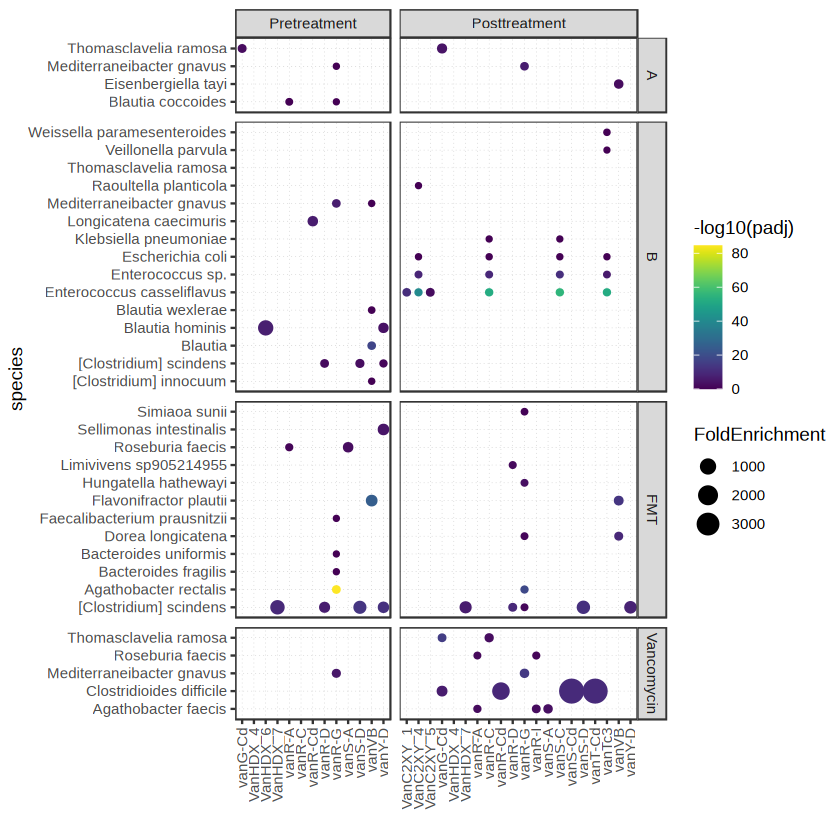

In [111]:
vrdf.st = vrdf.st[vrdf.st$condition %in% c("Pretreatment","Posttreatment"),]
vrdf.st$condition = factor(vrdf.st$condition,levels = c("Pretreatment","Posttreatment"))
p3.3 = ggplot(vrdf.st) + 
      geom_point(aes(x = gene,y = species,size = FoldEnrichment,color = -log10(padj))) + 
      facet_grid(group~condition,space = "free",scales = "free") +
      scale_color_viridis(option = "D") +
      scale_size_continuous(range = c(1,6)) +
    #scale_size_continuous(range = c(1, 5),limits = c(NA, max(pbidf.st$FoldEnrichment))) +
      #scale_color_gradient2(low = "#A8F1FF",high = "red",mid = "#FFDCDC",midpoint = 2) +
    #  coord_fixed() + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5),
          panel.grid.major = element_line(colour = "grey",linewidth = 0.1,linetype = 3) 
         ) + xlab("")
p3.3
ggexport(p3.3, 
         filename = "../downstream_analysis/figures/f5.1_van_enrich_score_heatmap_25_08_21.pdf",
         width = 8,height = 6)

In [7]:
#cor van
library(ComplexHeatmap)
#vrdft$count = 1
vrdf$count = 1
#vrdf.gen = dcast(vrdft,name~gene,value.var = "count",fun.aggregate = sum)
vrdf.gen = dcast(vrdf,name~gene,value.var = "count",fun.aggregate = sum)
head(vrdf.gen)
rownames(vrdf.gen) = vrdf.gen$name;vrdf.gen = vrdf.gen[,-1]
#dim(vrdf.gen)
gen.cor = cor(as.matrix(vrdf.gen))
gen.cor.hub = as.data.frame(gen.cor)
gen.cor.hub = gen.cor.hub[rowSums(gen.cor.hub)>1.5,]
dim(gen.cor.hub)

,name,vanAo2,VanC1XY_1,VanC2XY_1,VanC2XY_2,VanC2XY_4,VanC2XY_5,VanC4XY_2,vanG-Cd,VanG2XY_1,⋯,vanS-C,vanS-Cd,vanS-D,vanT-C,vanT-Cd,vanTc3,vanVB,vanXY-C,vanY-D,vanY-G1
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AAACCTG_AGACATA_ATTACTC,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,AAACCTG_AGACATA_GTAATCG,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,AAACCTG_AGTTACG_TCAGATG,0,0,0,0,0,0,0,1,0,⋯,0,0,0,0,0,0,0,0,0,0
4,AAACCTG_CGCGGTA_CTTGGCT,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,AAACCTG_CTTCTCT_AGCGGTC,0,0,0,0,1,0,0,0,0,⋯,1,0,0,0,0,1,0,0,0,0
6,AAACCTG_GGGTTGC_TAAGCGT,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 13 32

In [246]:
unique(vrdft$class)

[1] "Clostridia"            "Gammaproteobacteria"   "Bacilli"              
 [4] "Negativicutes"         "Erysipelotrichia"      "Bacteroidia"          
 [7] "Coriobacteriia"        "Desulfovibrionia"      "Verrucomicrobiia"     
[10] "Actinomycetes"         "Tissierellia"          "Fusobacteriia"        
[13] "Epsilonproteobacteria"

In [220]:
library(circlize)
pdf("../downstream_analysis/figures/f5.1_van_gene_cor_heatmap_total_25_09_12.pdf",width = 25,height = 25)
#hubgene = vrdf.gen
p = Heatmap(gen.cor[rownames(gen.cor.hub),
                rownames(gen.cor.hub)],col= colorRamp2(c(0,0.3,1), c("#669bbc","#ffe5ec","red")),
            show_column_dend = F,show_row_dend = F)
print(p)
dev.off()

pdf 
  2

,gene,[Clostridium] innocuum_FMT1_Pretreatment,[Clostridium] innocuum_FMT2_Pretreatment,[Clostridium] innocuum_Vancomycin1_Ontreatment,[Clostridium] innocuum_Vancomycin1_Posttreatment,[Clostridium] innocuum_Vancomycin2_Posttreatment,[Clostridium] innocuum_Vancomycin2_Pretreatment,[Clostridium] scindens_FMT1_Ontreatment,[Clostridium] scindens_FMT1_Posttreatment,[Clostridium] scindens_FMT1_Pretreatment,⋯,Thomasclavelia ramosa_FMT2_Posttreatment,Thomasclavelia ramosa_FMT2_Pretreatment,Thomasclavelia ramosa_Vancomycin1_Posttreatment,Thomasclavelia ramosa_Vancomycin2_Pretreatment,Veillonella parvula_FMT1_Pretreatment,Veillonella parvula_Vancomycin1_Ontreatment,Veillonella parvula_Vancomycin1_Pretreatment,Veillonella parvula_Vancomycin2_Posttreatment,Wansuia hejianensis_FMT2_Posttreatment,Weissella paramesenteroides_Vancomycin2_Posttreatment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,VanC1XY_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,VanC2XY_1,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,2,0,0
3,VanC2XY_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,VanC2XY_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,2,0,1
5,VanC2XY_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,VanC4XY_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 49 53

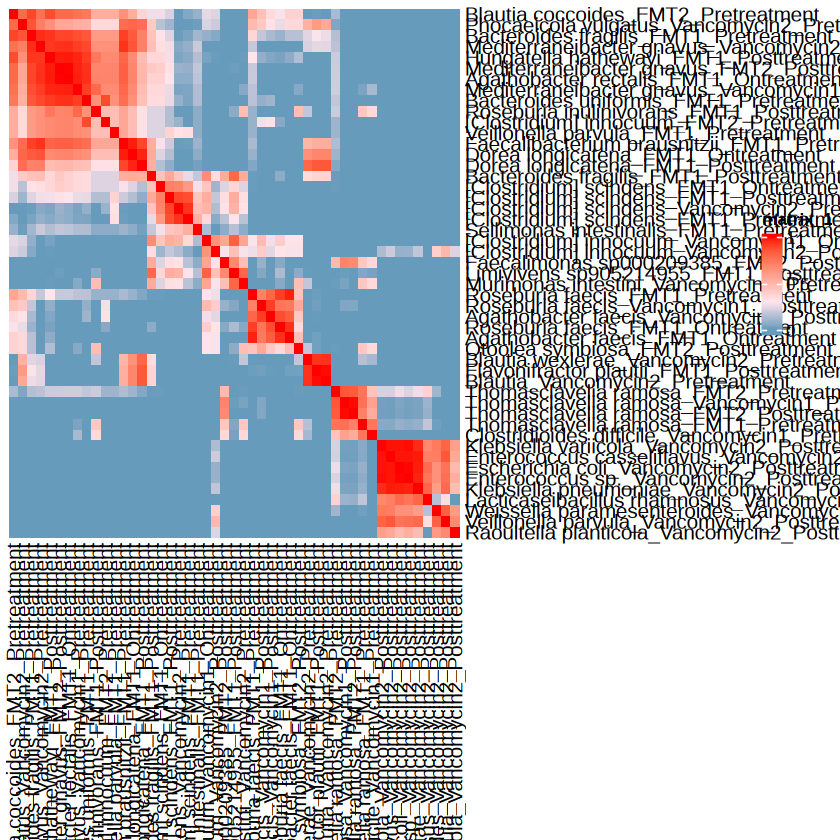

In [9]:
#cor species
library(ComplexHeatmap)
library(circlize)
vrdf$count = 1
vrdf.gen = dcast(vrdf[!vrdf$species %in% c("unclassfied","unclassfied_bacteria"),],
                 gene~species+group+condition,value.var = "count",fun.aggregate = sum)
head(vrdf.gen)
rownames(vrdf.gen) = vrdf.gen$gene;vrdf.gen = vrdf.gen[,-1]
vrdf.gen = vrdf.gen[,colSums(vrdf.gen > 0) > 1]
gen.cor = cor(as.matrix(vrdf.gen))
gen.cor.hub = as.data.frame(gen.cor)
gen.cor.hub = gen.cor.hub[rowSums(gen.cor.hub)>1.2,]
dim(gen.cor.hub)

#hubgene = vrdf.gen
Heatmap(gen.cor[rownames(gen.cor.hub),
                rownames(gen.cor.hub)],col= colorRamp2(c(0,0.3,1), c("#669bbc","#ffe5ec","red")),
            show_column_dend = F,show_row_dend = F)

In [51]:
library(RColorBrewer)
set2_colors <- brewer.pal(n = 4, name = "Set2")
print(set2_colors)
library("scales")
nejm_colors = pal_nejm("default")(3)

group_vector <- setNames(
  MySplit(rownames(gen.cor.hub),"_",2),
  rownames(gen.cor.hub)
)
group_colors <- setNames(
  set2_colors,
  c("FMT1","FMT2","Vancomycin1","Vancomycin2")
)
column_ha <- HeatmapAnnotation(
  Group = group_vector, # 传入分组向量
  col = list(Group = group_colors), # 指定颜色映射
  annotation_name_side = "left", # 注释名称的位置，通常在左侧或右侧
  annotation_legend_param = list( # 图例参数设置
    Group = list(title = "Sample", 
                 title_position = "topleft")
  ),
  show_annotation_name = TRUE # 显示注释的名称（"Group"）
)

group_vector <- setNames(
  MySplit(rownames(gen.cor.hub),"_",3),
  rownames(gen.cor.hub)
)
group_colors <- setNames(
  nejm_colors,
  c("Pretreatment","Ontreatment","Posttreatment")
)
column_ha2 <- HeatmapAnnotation(
  Group = group_vector, # 传入分组向量
  col = list(Group = group_colors), # 指定颜色映射
  annotation_name_side = "left", # 注释名称的位置，通常在左侧或右侧
  annotation_legend_param = list( # 图例参数设置
    Group = list(title = "Condition", 
                 title_position = "topleft")
  ),
  show_annotation_name = TRUE # 显示注释的名称（"Group"）
)


group_vector <- setNames(
  tax_df[match(MySplit(rownames(gen.cor.hub),"_",1),tax_df$species),]$order,
  rownames(gen.cor.hub)
)
# group_colors <- setNames(
#   nejm_colors,
#   c("Pretreatment","Ontreatment","Posttreatment")
# )
column_ha3 <- HeatmapAnnotation(
  Group = group_vector, # 传入分组向量
  col = list(Group = color_vector), # 指定颜色映射
  annotation_name_side = "left", # 注释名称的位置，通常在左侧或右侧
  annotation_legend_param = list( # 图例参数设置
    Group = list(title = "Class", 
                 title_position = "topleft")
  ),
  show_annotation_name = TRUE # 显示注释的名称（"Group"）
)

[1] "#66C2A5" "#FC8D62" "#8DA0CB" "#E78AC3"


[Clostridium] innocuum_FMT2_Pretreatment 
                                             "#67B575" 
        [Clostridium] innocuum_Vancomycin1_Ontreatment 
                                             "#67B575" 
      [Clostridium] innocuum_Vancomycin2_Posttreatment 
                                             "#67B575" 
               [Clostridium] scindens_FMT1_Ontreatment 
                                             "#85C491" 
             [Clostridium] scindens_FMT1_Posttreatment 
                                             "#85C491" 
              [Clostridium] scindens_FMT1_Pretreatment 
                                             "#85C491" 
       [Clostridium] scindens_Vancomycin2_Pretreatment 
                                             "#85C491" 
                  Agathobacter faecis_FMT1_Ontreatment 
                                             "#C2E1C7" 
         Agathobacter faecis_Vancomycin1_Posttreatment 
                                             "#C2E1C7" 
                Agathobacter rectalis_FMT1_Ontreatment 
                                             "#C2E1C7" 
               Bacteroides fragilis_FMT1_Posttreatment 
                                             "#E41A1C" 
                Bacteroides fragilis_FMT1_Pretreatment 
                                             "#E41A1C" 
               Bacteroides uniformis_FMT1_Pretreatment 
                                             "#E41A1C" 
                      Blautia_Vancomycin2_Pretreatment 
                                             "#C2E1C7" 
                   Blautia coccoides_FMT2_Pretreatment 
                                             "#C2E1C7" 
             Blautia wexlerae_Vancomycin2_Pretreatment 
                                             "#C2E1C7" 
     Clostridioides difficile_Vancomycin1_Pretreatment 
                                             "#E0F0E3" 
                    Dorea longicatena_FMT1_Ontreatment 
                                             "#C2E1C7" 
                  Dorea longicatena_FMT1_Posttreatment 
                                             "#C2E1C7" 
  Enterococcus casseliflavus_Vancomycin2_Posttreatment 
                                             "#FFF52F" 
            Enterococcus sp._Vancomycin2_Posttreatment 
                                             "#FFF52F" 
            Escherichia coli_Vancomycin2_Posttreatment 
                                             "#9F5196" 
        Faecalibacterium prausnitzii_FMT1_Pretreatment 
                                             "#85C491" 
           Faecalimonas sp000209385_FMT2_Posttreatment 
                                             "#C2E1C7" 
             Flavonifractor plautii_FMT1_Posttreatment 
                                             "#85C491" 
               Hungatella hathewayi_FMT1_Posttreatment 
                                             "#C2E1C7" 
       Klebsiella pneumoniae_Vancomycin2_Posttreatment 
                                             "#9F5196" 
        Klebsiella variicola_Vancomycin2_Posttreatment 
                                             "#9F5196" 
Lacticaseibacillus rhamnosus_Vancomycin2_Posttreatment 
                                             "#FFF52F" 
             Limivivens sp905214955_FMT1_Posttreatment 
                                             "#C2E1C7" 
          Mediterraneibacter gnavus_FMT2_Posttreatment 
                                             "#C2E1C7" 
    Mediterraneibacter gnavus_Vancomycin1_Pretreatment 
                                             "#C2E1C7" 
    Mediterraneibacter gnavus_Vancomycin2_Pretreatment 
                                             "#C2E1C7" 
          Murimonas intestini_Vancomycin2_Pretreatment 
                                             "#C2E1C7" 
                   Otoolea symbiosa_FMT2_Posttreatment 
                                             "#C2E1C7" 
         Phocaeicola vulgatus_Vancomycin2_Pretreatment 
                                      

Warning message:
"Following annotation names are duplicated: Group"


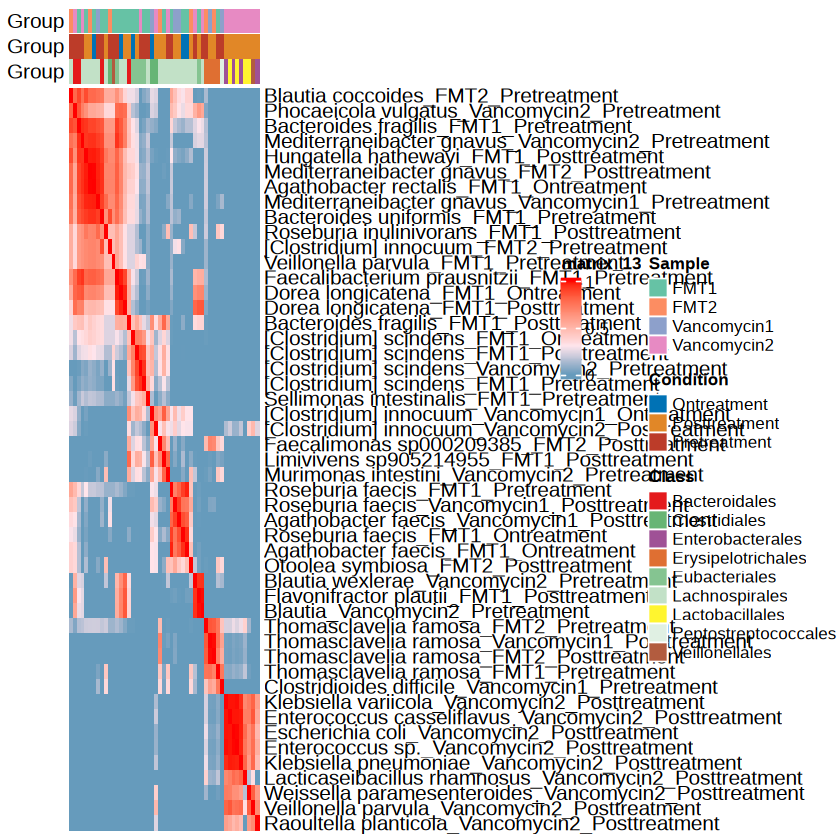

In [53]:
Heatmap(gen.cor[rownames(gen.cor.hub),
                rownames(gen.cor.hub)],
            col= colorRamp2(c(0,0.3,1), c("#669bbc","#ffe5ec","red")),
            show_column_dend = F,show_row_dend = F,show_column_names = F,
        top_annotation = c("Sample" = column_ha,"Condition" = column_ha2,"Order" = column_ha3))

In [ ]:
pdf("../downstream_analysis/figures/f5.1_van_species_cor_heatmap_25_09_27.pdf",width = 12,height = 7)
Heatmap(gen.cor[rownames(gen.cor.hub),
                rownames(gen.cor.hub)],
            col= colorRamp2(c(0,0.3,1), c("#669bbc","#ffe5ec","red")),
            show_column_dend = F,show_row_dend = F,show_column_names = F,
        top_annotation = c(column_ha,column_ha2,column_ha3))
dev.off()

Warning message:
"Following annotation names are duplicated: Group"


In [277]:
pht = Heatmap(gen.cor[rownames(gen.cor.hub),
                rownames(gen.cor.hub)],col= colorRamp2(c(0,0.3,1), c("#669bbc","#ffe5ec","red")),
            show_column_dend = F,show_row_dend = F)
pht
row_orders <- row_order(pht)
print(row_orders)

Warning message:
"The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`."


 [1] 15 36 12 33 26 31 10 32 13 41  1 47 23 18 19 11  4  5  7  6 42  2  3 24 30
[26] 34 39 40  9 38  8 35 16 25 14 45 46 44 43 17 28 20 22 21 27 29 49 48 37


In [290]:
vrdf.st.spc

,species,group,condition,gene,Gram_Stain,celln,cellnt,prop,mygroup
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<fct>
190,Murimonas intestini,Vancomycin2,Pretreatment,vanR-Cd,Positive,1,2,0.50000000,Murimonas intestini_Vancomycin2_Pretreatment
191,Murimonas intestini,Vancomycin2,Pretreatment,vanR-D,Positive,1,2,0.50000000,Murimonas intestini_Vancomycin2_Pretreatment
127,Enterococcus sp.,Vancomycin2,Posttreatment,vanS-C,Positive,27,73,0.36986301,Enterococcus sp._Vancomycin2_Posttreatment
126,Enterococcus sp.,Vancomycin2,Posttreatment,vanR-C,Positive,24,73,0.32876712,Enterococcus sp._Vancomycin2_Posttreatment
116,Enterococcus casseliflavus,Vancomycin2,Posttreatment,vanS-C,Positive,107,331,0.32326284,Enterococcus casseliflavus_Vancomycin2_Posttreatment
119,Enterococcus casseliflavus,Vancomycin2,Posttreatment,vanTc3,Positive,102,331,0.30815710,Enterococcus casseliflavus_Vancomycin2_Posttreatment
115,Enterococcus casseliflavus,Vancomycin2,Posttreatment,vanR-C,Positive,101,331,0.30513595,Enterococcus casseliflavus_Vancomycin2_Posttreatment
125,Enterococcus sp.,Vancomycin2,Posttreatment,VanC2XY_4,Positive,22,73,0.30136986,Enterococcus sp._Vancomycin2_Posttreatment
128,Enterococcus sp.,Vancomycin2,Posttreatment,vanTc3,Positive,20,73,0.27397260,Enterococcus sp._Vancomycin2_Posttreatment


`summarise()` has grouped output by 'species', 'gene', 'group', 'condition'.
You can override using the `.groups` argument.
`summarise()` has grouped output by 'species', 'group'. You can override using
the `.groups` argument.


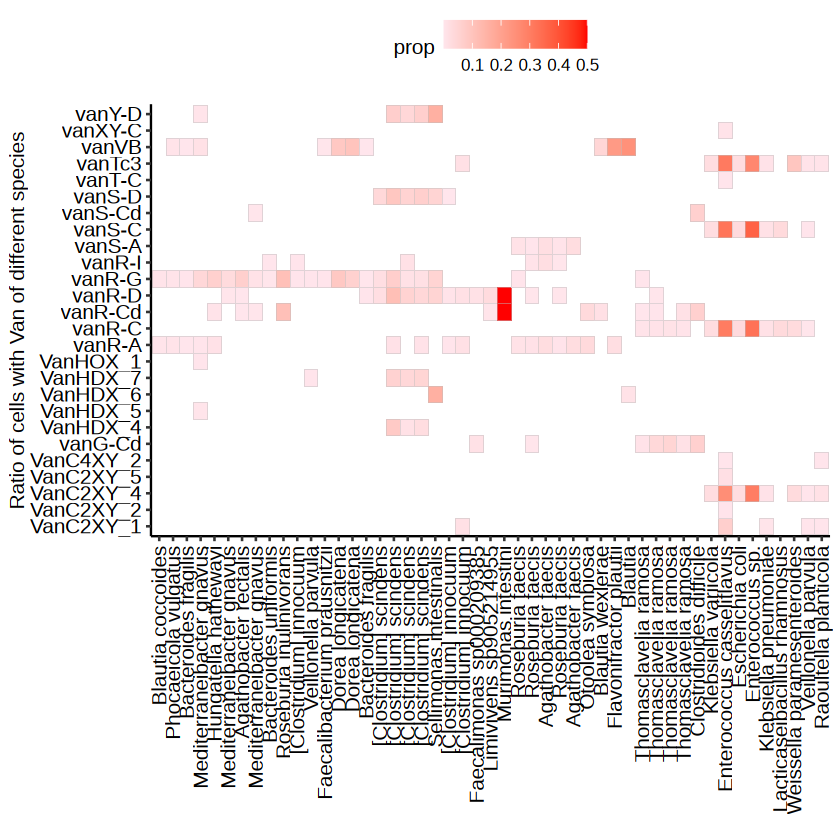

file saved to ../downstream_analysis/figures/f5.1_van_ratio_heatmap_species_25_09_12.pdf



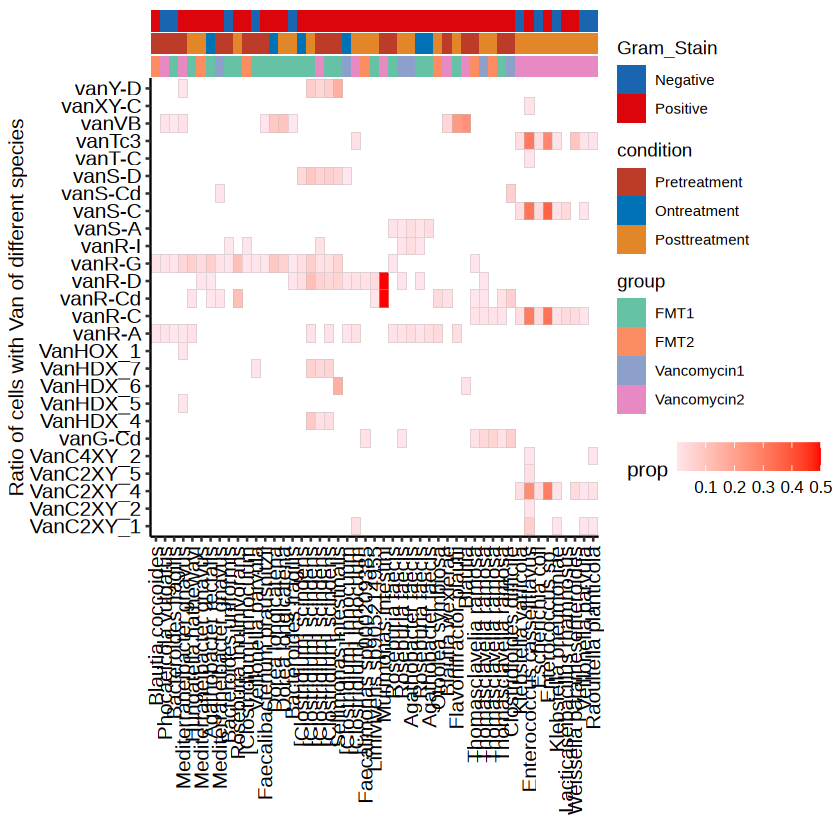

In [294]:
#calculate van gene correlation
# hubid = c("Clostridioides difficile_FMT1","Clostridioides difficile_FMT2",
#           "Clostridioides difficile_Vancomycin2","Clostridioides difficile_Vancomycin1",
#           rownames(gen.cor.hub)[row_orders])
hubid = c(rownames(gen.cor.hub)[row_orders])
vrdf.st.spc = vrdf %>% group_by(species,gene,group,condition,Gram_Stain) %>% dplyr::summarise(celln = length(unique(name)))
cell.st.spc = anotdf %>% group_by(species,group,condition) %>% dplyr::summarise(cellnt = length(unique(name)))
vrdf.st.spc = merge(vrdf.st.spc,cell.st.spc,by = c("species","group","condition"))
#vrdf.st.spc = vrdf.st.spc %>% group_by(gene,group) %>% filter(length(species) > 10)
vrdf.st.spc$prop = vrdf.st.spc$celln/vrdf.st.spc$cellnt
vrdf.st.spc = vrdf.st.spc[order(-vrdf.st.spc$prop),]
#vrdf.st.spc = vrdf.st.spc[vrdf.st.spc$specie,]
# vrdf.st.spc = vrdf.st.spc[vrdf.st.spc$cellnt > 30,]
# vrdf.st.spc = vrdf.st.spc[vrdf.st.spc$prop > 0.01,]
#vrdf.st.spc$species = factor(vrdf.st.spc$species,levels = unique(vrdf.st.spc$species))
# vrdf.st.spc_complete <- vrdf.st.spc %>%
#   tidyr::complete(species,group, gene, fill = list(celln = NA, cellnt = NA, prop = NA))
#vrdf.st.spc_complete = merge(vrdf.st.spc_complete,taxan,by = "species")
vrdf.st.spc$mygroup = paste0(vrdf.st.spc$species,"_",vrdf.st.spc$group,"_",vrdf.st.spc$condition)
vrdf.st.spc = vrdf.st.spc[vrdf.st.spc$mygroup %in% hubid,]
#vrdf.st.spc = vrdf.st.spc[order(vrdf.st.spc$species),]
vrdf.st.spc$mygroup = factor(vrdf.st.spc$mygroup,levels = unique(hubid))
vrdf.st.spc = vrdf.st.spc[order(vrdf.st.spc$mygroup),]
mylabels = unique(as.character(vrdf.st.spc$mygroup))
mylabels = MySplit(mylabels,"_",1)
p5.0 = ggplot(vrdf.st.spc,aes(x = mygroup,y = gene,fill = prop)) + 
    geom_tile(color = "grey") +
    scale_x_discrete(labels = mylabels) +
    scale_fill_gradient(low = "#ffe5ec",high = "red",na.value = "white") +
    #scale_fill_viridis(option = "D",na.value = "black") +
    #scale_color_npg() +
    theme_pubr() +
    xlab("") + ylab("Ratio of cells with Van of different species") +
    #coord_fixed() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p5.0
library(aplot)
# 构建物种类型注释层
species_type = unique(vrdf.st.spc[,c("mygroup","group","condition","Gram_Stain","species")])
species_type$condition = factor(species_type$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
p_annotation1 <- ggplot(species_type, aes(x = mygroup, y = 1, fill = group)) +
  geom_tile() +
  scale_fill_brewer(palette = "Set2") +
  theme_void() +  # 隐藏坐标轴
  labs(x = NULL, y = NULL)
p_annotation2 <- ggplot(species_type, aes(x = mygroup, y = 1, fill = condition)) +
  geom_tile() +
  scale_fill_nejm() +
  theme_void() +  # 隐藏坐标轴
  labs(x = NULL, y = NULL)
p_annotation3 <- ggplot(species_type, aes(x = mygroup, y = 1, fill = Gram_Stain)) +
  geom_tile() +
  scale_fill_discreterainbow() +
  theme_void() +  # 隐藏坐标轴
  labs(x = NULL, y = NULL)

#拼接：将注释置于主图下方
p5.0 = p5.0 %>% 
  insert_top(p_annotation1, height = 0.05)  %>% 
  insert_top(p_annotation2, height = 0.05) %>% 
  insert_top(p_annotation3, height = 0.05) 
p5.0
ggexport(p5.0, 
         filename = "../downstream_analysis/figures/f5.1_van_ratio_heatmap_species_25_09_12.pdf",
         width = 12,height = 7)

In [329]:
#cor species
library(ComplexHeatmap)
library(circlize)
vrdft$count = 1
vrdf.gen = dcast(vrdft[!vrdft$species %in% c("unclassfied","unclassfied_bacteria"),],
                 gene~species+group+condition,value.var = "count",fun.aggregate = sum)
head(vrdf.gen)
rownames(vrdf.gen) = vrdf.gen$gene;vrdf.gen = vrdf.gen[,-1]
vrdf.gen = vrdf.gen[,colSums(vrdf.gen > 0) > 5]
gen.cor = cor(as.matrix(vrdf.gen))
gen.cor.hub = as.data.frame(gen.cor)
gen.cor.hub = gen.cor.hub[rowSums(gen.cor.hub)>1.2,]
dim(gen.cor.hub)
#hubgene = vrdf.gen
Heatmap(gen.cor[rownames(gen.cor.hub),
                rownames(gen.cor.hub)],col= colorRamp2(c(0,0.3,1), c("#669bbc","#ffe5ec","red")),
            show_column_dend = F,show_row_dend = F)

library(RColorBrewer)
set2_colors <- brewer.pal(n = 4, name = "Set2")
print(set2_colors)
library("scales")
nejm_colors = pal_nejm("default")(3)
group_vector <- setNames(
  MySplit(rownames(gen.cor.hub),"_",2),
  rownames(gen.cor.hub)
)
group_colors <- setNames(
  set2_colors,
  c("FMT1","FMT2","Vancomycin1","Vancomycin2")
)
column_ha <- HeatmapAnnotation(
  Group = group_vector, # 传入分组向量
  col = list(Group = group_colors), # 指定颜色映射
  annotation_name_side = "left", # 注释名称的位置，通常在左侧或右侧
  annotation_legend_param = list( # 图例参数设置
    Group = list(title = "Sample", 
                 title_position = "topleft")
  ),
  show_annotation_name = TRUE # 显示注释的名称（"Group"）
)

group_vector <- setNames(
  MySplit(rownames(gen.cor.hub),"_",3),
  rownames(gen.cor.hub)
)
group_colors <- setNames(
  nejm_colors,
  c("Pretreatment","Ontreatment","Posttreatment")
)
column_ha2 <- HeatmapAnnotation(
  Group = group_vector, # 传入分组向量
  col = list(Group = group_colors), # 指定颜色映射
  annotation_name_side = "left", # 注释名称的位置，通常在左侧或右侧
  annotation_legend_param = list( # 图例参数设置
    Group = list(title = "Condition", 
                 title_position = "topleft")
  ),
  show_annotation_name = TRUE # 显示注释的名称（"Group"）
)


group_vector <- setNames(
  tax_df[match(MySplit(rownames(gen.cor.hub),"_",1),tax_df$species),]$class,
  rownames(gen.cor.hub)
)
# group_colors <- setNames(
#   nejm_colors,
#   c("Pretreatment","Ontreatment","Posttreatment")
# )
column_ha3 <- HeatmapAnnotation(
  Group = group_vector, # 传入分组向量
  # col = list(Group = group_colors), # 指定颜色映射
  annotation_name_side = "left", # 注释名称的位置，通常在左侧或右侧
  annotation_legend_param = list( # 图例参数设置
    Group = list(title = "Class", 
                 title_position = "topleft")
  ),
  show_annotation_name = TRUE # 显示注释的名称（"Group"）
)

,gene,[Clostridium] asparagiforme_FMT1_Ontreatment,[Clostridium] asparagiforme_FMT1_Posttreatment,[Clostridium] hylemonae_FMT1_Ontreatment,[Clostridium] hylemonae_FMT1_Posttreatment,[Clostridium] hylemonae_FMT1_Pretreatment,[Clostridium] hylemonae_FMT2_Posttreatment,[Clostridium] innocuum_FMT1_Ontreatment,[Clostridium] innocuum_FMT1_Posttreatment,[Clostridium] innocuum_FMT1_Pretreatment,⋯,Veillonella parvula_Vancomycin1_Ontreatment,Veillonella parvula_Vancomycin1_Posttreatment,Veillonella parvula_Vancomycin1_Pretreatment,Veillonella parvula_Vancomycin2_Posttreatment,Veillonella parvula_Vancomycin2_Pretreatment,Veillonella rogosae_FMT2_Pretreatment,Vescimonas fastidiosa_FMT1_Pretreatment,Wansuia hejianensis_FMT2_Posttreatment,Weissella paramesenteroides_Vancomycin2_Posttreatment,Zongyangia gallinarum_FMT2_Posttreatment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,(AGly)aadA1-pm,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,(AGly)aph7,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,(Bla)ampH,0,0,0,0,0,0,0,0,0,⋯,0,1,0,5,0,0,0,0,0,0
4,(Bla)blaLEN-24,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,(Bla)PBP1a,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,(Bla)PBP1b,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 212 214

[1] "#66C2A5" "#FC8D62" "#8DA0CB" "#E78AC3"


In [330]:
pdf("../downstream_analysis/figures/f5.1_total_ARGs_species_cor_heatmap_25_09_12.pdf",width = 10,height = 7)
Heatmap(gen.cor[rownames(gen.cor.hub),
                rownames(gen.cor.hub)],
            col= colorRamp2(c(0,0.3,1), c("#669bbc","#ffe5ec","red")),
            show_column_dend = F,show_row_dend = F,show_column_names = F,show_row_names = F,
        top_annotation = c("Sample" = column_ha,"Condition" = column_ha2,"Class" = column_ha3))
dev.off()

Warning message:
"Following annotation names are duplicated: Group"


pdf 
  2

`summarise()` has grouped output by 'species', 'gene', 'group', 'condition'.
You can override using the `.groups` argument.
`summarise()` has grouped output by 'species', 'group'. You can override using
the `.groups` argument.


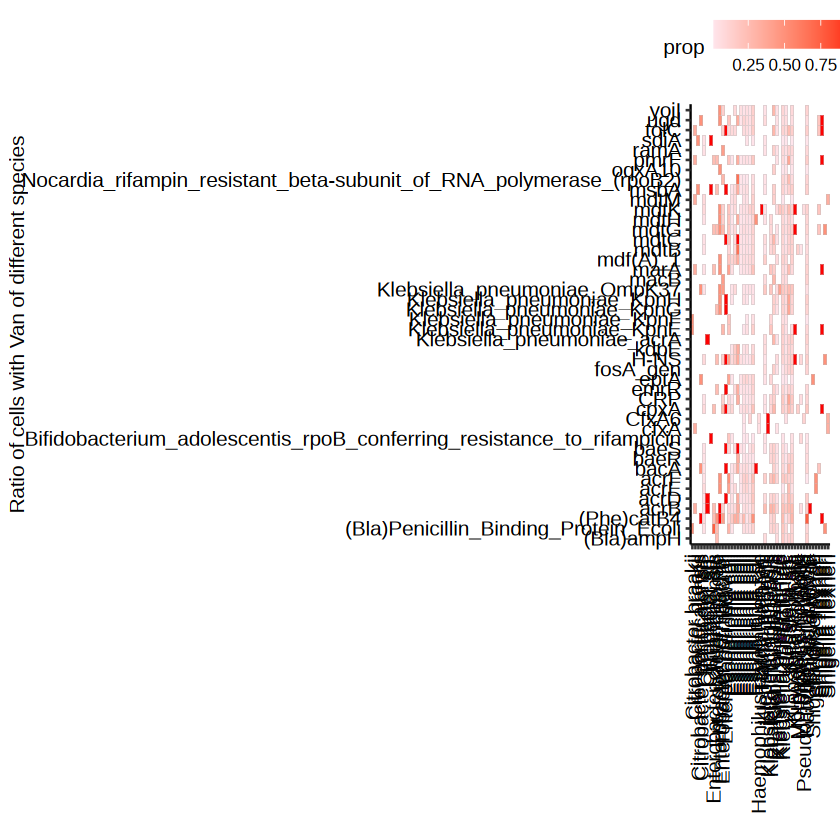

file saved to ../downstream_analysis/figures/f5.1_ARGs_Gammaprotein_ratio_heatmap_species_25_09_12.pdf



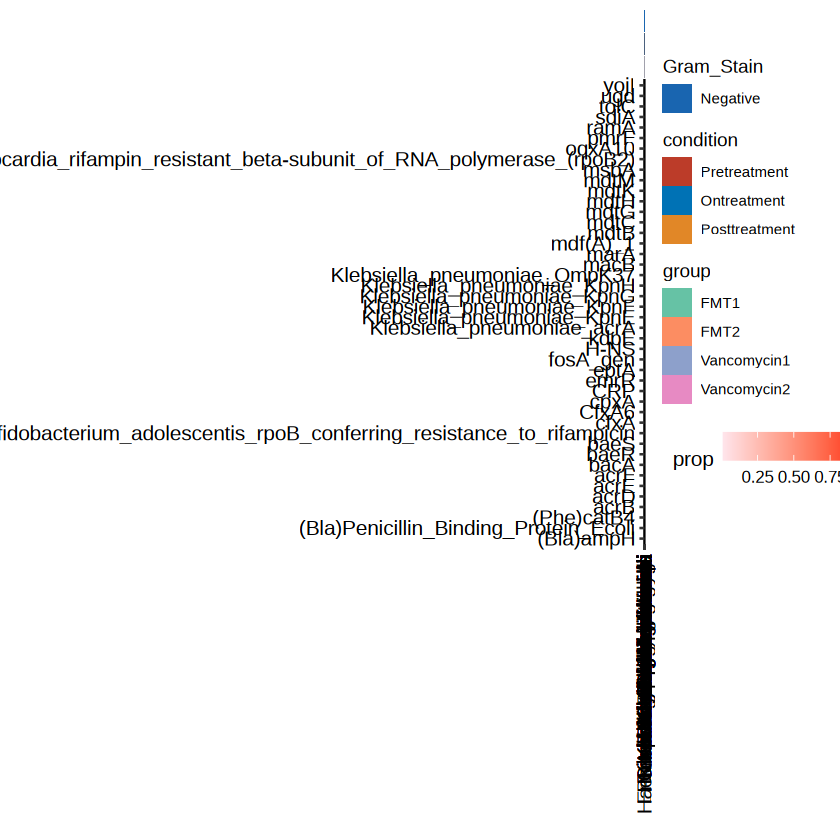

In [341]:
#calculate van gene correlation
# hubid = c("Clostridioides difficile_FMT1","Clostridioides difficile_FMT2",
#           "Clostridioides difficile_Vancomycin2","Clostridioides difficile_Vancomycin1",
#           rownames(gen.cor.hub)[row_orders])
vrdf.st.spc = vrdft[vrdft$class %in% "Gammaproteobacteria",] %>% group_by(species,gene,group,condition,Gram_Stain) %>% dplyr::summarise(celln = length(unique(name)))
cell.st.spc = anotdf %>% group_by(species,group,condition) %>% dplyr::summarise(cellnt = length(unique(name)))
vrdf.st.spc = merge(vrdf.st.spc,cell.st.spc,by = c("species","group","condition"))
#vrdf.st.spc = vrdf.st.spc %>% group_by(gene,group) %>% filter(length(species) > 10)
vrdf.st.spc$prop = vrdf.st.spc$celln/vrdf.st.spc$cellnt
vrdf.st.spc = vrdf.st.spc[vrdf.st.spc$prop > 0.01,]
vrdf.st.spc = vrdf.st.spc %>% group_by(gene) %>% filter(length(unique(species)) > 5)
#vrdf.st.spc$species = factor(vrdf.st.spc$species,levels = unique(vrdf.st.spc$species))
# vrdf.st.spc_complete <- vrdf.st.spc %>%
#   tidyr::complete(species,group, gene, fill = list(celln = NA, cellnt = NA, prop = NA))
#vrdf.st.spc_complete = merge(vrdf.st.spc_complete,taxan,by = "species")
vrdf.st.spc$mygroup = paste0(vrdf.st.spc$species,"_",vrdf.st.spc$group,"_",vrdf.st.spc$condition)
vrdf.st.spc = vrdf.st.spc[order(vrdf.st.spc$mygroup),]
mylabels = unique(as.character(vrdf.st.spc$mygroup))
mylabels = MySplit(mylabels,"_",1)

p5.1 = ggplot(vrdf.st.spc,aes(x = mygroup,y = gene,fill = prop)) + 
    geom_tile(color = "grey") +
    scale_x_discrete(labels = mylabels) +
    scale_fill_gradient(low = "#ffe5ec",high = "red",na.value = "white") +
    #scale_fill_viridis(option = "D",na.value = "black") +
    #scale_color_npg() +
    theme_pubr() +
    xlab("") + ylab("Ratio of cells with Van of different species") +
    #coord_fixed() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p5.1
library(aplot)
# 构建物种类型注释层
species_type = unique(vrdf.st.spc[,c("mygroup","group","condition","Gram_Stain","species")])
species_type$condition = factor(species_type$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
p_annotation1 <- ggplot(species_type, aes(x = mygroup, y = 1, fill = group)) +
  geom_tile() +
  scale_fill_brewer(palette = "Set2") +
  theme_void() +  # 隐藏坐标轴
  labs(x = NULL, y = NULL)
p_annotation2 <- ggplot(species_type, aes(x = mygroup, y = 1, fill = condition)) +
  geom_tile() +
  scale_fill_nejm() +
  theme_void() +  # 隐藏坐标轴
  labs(x = NULL, y = NULL)
p_annotation3 <- ggplot(species_type, aes(x = mygroup, y = 1, fill = Gram_Stain)) +
  geom_tile() +
  scale_fill_discreterainbow() +
  theme_void() +  # 隐藏坐标轴
  labs(x = NULL, y = NULL)

#拼接：将注释置于主图下方
p5.1 = p5.1 %>% 
  insert_top(p_annotation1, height = 0.05)  %>% 
  insert_top(p_annotation2, height = 0.05) %>% 
  insert_top(p_annotation3, height = 0.05) 
p5.1
ggexport(p5.1, 
         filename = "../downstream_analysis/figures/f5.1_ARGs_Gammaprotein_ratio_heatmap_species_25_09_12.pdf",
         width = 15,height = 10)

## Figure5S

In [ ]:
cmpsp = anidf %>% group_by(group,condition,sample) %>% 
            mutate(cellnt = length(unique(name)))
cmpsp = cmpsp %>% group_by(group,condition,sample,species) %>% 
            summarise(celln = length(unique(name)),cellp = celln/cellnt[1])
cmpspmx = dcast(cmpsp,species~sample,value.var = "cellp")
rownames(cmpspmx) = cmpspmx$species;cmpspmx = cmpspmx[,-1]
cmpspmx[is.na(cmpspmx)] = 0
cmpspmx = dcast(cmpsp,species+group~condition,value.var = "cellp")
cmpspmx[is.na(cmpspmx)] = 0
head(cmpspmx)
cmpspmx = merge(cmpspmx,tax_df,by = "species")
head(cmpspmx)

In [ ]:
library(dplyr)
library(tidyr)
library(vegan)
jaccard_similarity <- function(set1, set2) {
  intersection <- length(intersect(set1, set2))
  union <- length(union(set1, set2))
  similarity <- intersection / union
  return(similarity)
}

presence_data <- cmpsp %>%
  select(sample, species) %>%
  distinct() %>% 
  mutate(presence = 1)

presence_wide <- presence_data %>%
  pivot_wider(names_from = species, 
              values_from = presence, 
              values_fill = 0)


sample_names <- presence_wide$sample
presence_mat = presence_wide[,-c(1,2,3)]
rownames(presence_mat) <- sample_names
presence_mat <- as.matrix(presence_mat) 
#presence_mat

jaccard_distance <- vegdist(presence_mat, method = "jaccard")

jaccard_similarity <- 1 - as.matrix(jaccard_distance)

pheatmap(jaccard_similarity)
jcdf = melt(jaccard_similarity)
#head(jcdf)
jcdf$Var1 = as.character(jcdf$Var1)
jcdf$Var2 = as.character(jcdf$Var2)
jcdf = jcdf[MySplit(jcdf$Var1,"_",1) == MySplit(jcdf$Var2,"_",1),]
jcdf = jcdf[jcdf$Var1 != jcdf$Var2,]
#head(jcdf)
jcdf$group = MySplit(jcdf$Var1,"-",1)
jcdf = jcdf[MySplit(jcdf$Var1,"_",2) == "1w",]
#ggplot(jcdf,aes(x = group,y = value)) + geom_boxplot()
p1.0 = ggplot(jcdf,aes(x = Var2,y = value,fill = group)) + 
            geom_bar(stat = "identity",width = 0.5) + theme_pubr() + xlab("sample")
p1.0

In [ ]:
library(tidyplots)
head(jcdf)
p2.2 = ggplot(jcdf,aes(x = group,y = value)) + 
    geom_boxplot(width = 0.2,lwd = 0.5,outlier.shape = NA) +
    geom_point(aes(color = Var2),size = 3,alpha = 0.7,stroke.size = 0.5,position = position_dodge(0.1)) +
    #scale_fill_npg() +
    scale_color_brewer(palette = "Set3") +
    stat_compare_means(paired = TRUE,method = "t.test",comparisons = list(c("FMT","Van"))) + theme_pubr() + 
    xlab("") + ylab("Jaccard score of post-treated sample and pre-treated sample") + labs(color = "Samples") + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p2.2
ggexport(p2.2,filename = "../downstream_analysis/figures/species_treat_change_jaccard_score_25_10_10.pdf",width =5,height = 5.5)

In [ ]:
#head(cmpspmx2)

cmpspmx$diff1 = cmpspmx$`2w` - cmpspmx$`1w`
cmpspmx$diff2 = cmpspmx$`3w` - cmpspmx$`1w`
cmpspmx2 = dcast(cmpspmx,species~group,value.var = "diff1")
cmpspmx3 = dcast(cmpspmx[cmpspmx$group %in% c("FMT-2","Van-2"),],species~group,value.var = "diff2")
#cmpspmx3
rownames(cmpspmx2) = cmpspmx2$species;cmpspmx2 = cmpspmx2[,-1]
rownames(cmpspmx3) = cmpspmx3$species;cmpspmx3 = cmpspmx3[,-1]
colnames(cmpspmx3) = c("FMT-2_3W","Van-2_3W")
cmpspmx2 = merge(cmpspmx2,cmpspmx3,by = "row.names",all =TRUE)
rownames(cmpspmx2) = cmpspmx2$Row.names;cmpspmx2 = cmpspmx2[,-1]
head(cmpspmx2)
dim(cmpspmx2)
cmpspmx2[is.na(cmpspmx2)] = 0
cmpspmx2l = melt(cmpspmx2)
cmpspmx2 = cmpspmx2[rowSums(abs(cmpspmx2)) > 0.05,]
dim(cmpspmx2)
library(pheatmap)
cmpspmx2 = cmpspmx2[,c("FMT-1","FMT-2","FMT-2_3W","Van-1","Van-2","Van-2_3W")]
graman <- data.frame(
  species = c(
    "Bifidobacterium animalis", "Bifidobacterium breve", "Bifidobacterium bifidum", 
    "Bifidobacterium longum", "Enterococcus casseliflavus", "Bacteroides fragilis", 
    "Bacteroides thetaiotaomicron", "Bacteroides uniformis", "Phocaeicola vulgatus", 
    "Parabacteroides distasonis", "[Clostridium] innocuum", "[Clostridium] scindens", 
    "[Ruminococcus] torques", "Agathobacter rectalis", "Blautia coccoides", 
    "Blautia pseudococcoides", "Eisenbergiella porci", "Blautia", 
    "Mediterraneibacter faecis", "Faecalibacterium prausnitzii", "Faecalibacterium sp.", 
    "Ruminococcus bromii", "Ruthenibacterium lactatiformans", "Mediterraneibacter gnavus", 
    "Roseburia faecis", "Thomasclavelia ramosa", "Klebsiella pneumoniae", 
    "Raoultella planticola", "Escherichia coli", "Veillonella parvula", 
    "Peptonophilus genitalis"
  ),
  Gram_Stain = c(
    "Positive", "Positive", "Positive", "Positive", "Positive", "Negative", 
    "Negative", "Negative", "Negative", "Negative", "Positive", "Positive", 
    "Positive", "Positive", "Positive", "Positive", "Positive", "Positive", 
    "Positive", "Positive", "Positive", "Positive", "Positive", "Positive", 
    "Positive", "Positive", "Negative", "Negative", "Negative", "Negative", 
    "Positive"
  ),
  stringsAsFactors = FALSE
)
cmpspmx2.an = cmpspmx2
cmpspmx2.an$species = rownames(cmpspmx2.an)
cmpspmx2.an = merge(cmpspmx2.an,graman,by = "species")
cmpspmx2.an
library(RColorBrewer)
library(ComplexHeatmap)
set_colors <- brewer.pal(n = 2, name = "Set1")
#print(set_colors)
cmpspmx2.an = cmpspmx2.an[order(cmpspmx2.an$Gram_Stain),]
group_vector <- setNames(
  cmpspmx2.an$Gram_Stain,
  cmpspmx2.an$species
)
group_colors <- setNames(
  set_colors[1:2],
  c("Positive","Negative")
)
group_colors
row_ha <- rowAnnotation(
  Group = group_vector, # 指定注释数据
  col = list(Group = group_colors) # 指定颜色映射关系
)
cmpspmx2 = cmpspmx2[cmpspmx2.an$species,]
cmpspmx2 = as.matrix(cmpspmx2)
#row_ha
Heatmap(cmpspmx2,cluster_columns = FALSE,cluster_rows = TRUE,name = "Delta\nCellRatio",right_annotation = row_ha)

In [ ]:
head(cmpspmx2)
cmpspmx2$species = row.names(cmpspmx2)
nrow(cmpspmx2)
cmpspmx2 = merge(cmpspmx2,tax_df,by = "species")
nrow(cmpspmx2)
pls = list()
library(RColorBrewer)
my_colors <- brewer.pal(length(unique(cmpspmx2$class)), "Paired")
names(my_colors) = unique(cmpspmx2$class)
cmpspmxt = NULL
for(i in 1:6){
    cmpspmxi = cmpspmx2[,c(1,1+i,8,9)]
    cmpspmxi$sample = colnames(cmpspmxi)[2]
    colnames(cmpspmxi)[2] = "delta"
    cmpspmxi = cmpspmxi[abs(cmpspmxi$delta) > 0.05,]
    cmpspmxi = cmpspmxi[order(-cmpspmxi$delta),]
    cmpspmxi$species = factor(cmpspmxi$species,levels = cmpspmxi$species)
    pi = ggplot(cmpspmxi,aes(x = species,y = delta,fill = class)) + geom_bar(stat = "identity",width = 0.4) + 
    theme_pubr() + scale_fill_manual(values = my_colors) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + ggtitle(unique(cmpspmxi$sample)) +
    ylim(c(-0.35,0.35)) + ylab("Delta cell ratio") + xlab("")
    cmpspmxt = rbind(cmpspmxt,cmpspmxi)
    pls[[i]] = pi
}
#pls
cmpspmxt = cmpspmxt %>% group_by(group,species,class) %>% mutate(deltam = mean(delta),sd = sd(delta))
#cmpspmxt.st
#cmpspmxt = cmpspmxt[!is.na(cmpspmxt$sd),]
cmpspmxt.st.fmt = cmpspmxt[cmpspmxt$group == "FMT",]
#cmpspmxt.st.fmt
cmpspmxt.st.fmt = cmpspmxt.st.fmt[order(-cmpspmxt.st.fmt$deltam),]
cmpspmxt.st.fmt$species = factor(cmpspmxt.st.fmt$species,levels = unique(cmpspmxt.st.fmt$species))
pi1 = ggplot(cmpspmxt.st.fmt,aes(x = species,y = delta,fill = class,color = class)) +
    geom_hline(yintercept = 0,linetype = 2,alpha = 0.5) +
    #geom_bar(width = 0.05,stat = "identity") + 
    geom_boxplot(fill = NA,width = 0.5) +
    geom_point(aes(shape = sample),size = 1.5) + 
    
    theme_pubr() + scale_color_manual(values = my_colors) +
    scale_fill_manual(values = my_colors) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + 
    ylim(c(-0.3,0.3)) + ylab("Delta cell ratio") + xlab("") + ggtitle("FMT")

cmpspmxt.st.van = cmpspmxt[cmpspmxt$group != "FMT",]
#cmpspmxt.st.fmt
cmpspmxt.st.van = cmpspmxt.st.van[order(-cmpspmxt.st.van$deltam),]
cmpspmxt.st.van$species = factor(cmpspmxt.st.van$species,levels = unique(cmpspmxt.st.van$species))
pi2 = ggplot(cmpspmxt.st.van,aes(x = species,y = delta,fill = class,color = class)) +
    geom_hline(yintercept = 0,linetype = 2,alpha = 0.5) +
    geom_boxplot(fill = NA,width = 0.5,outlier.stroke = 0.5) +
    #geom_bar(width = 0.05,stat = "identity") + 
    geom_point(aes(shape = sample),size = 1.5) + 
    theme_pubr() + scale_color_manual(values = my_colors) +
    scale_fill_manual(values = my_colors) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + 
    ylim(c(-0.3,0.3)) + ylab("Delta cell ratio") + xlab("") + ggtitle("Van")
pt = ggarrange(pi1,pi2,legend = "right")
pt
ggexport(pt,filename = "../downstream_analysis/figures/species_treatchange_cellratio_0.05_barplot.pdf",width = 12,height = 7)
